<a href="https://colab.research.google.com/github/fbeilstein/bioinformatics/blob/master/practice_02_evolutionary_divergence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Computational Biology Toolkit: Biopython and NCBI

In this lab, we use **Biopython**, a collection of non-commercial Python tools for computational biology and bioinformatics. Specifically, we will use its `Entrez` module to interface directly with the biological databases maintained by the U.S. government.

Our sequences come from the **National Center for Biotechnology Information (NCBI)**, specifically the **RefSeq (Reference Sequence)** database. Unlike the standard GenBank database, which contains unverified submissions from individual researchers, RefSeq provides a comprehensively curated, non-redundant, and well-annotated set of sequences representing the accepted standard for an organism.

We are downloading mRNA transcripts (which include the protein-coding sequence and untranslated regions) rather than raw genomic DNA to avoid processing massive introns.

*   **Browse the Database:** You can manually search for genes, organisms, and accession numbers (e.g., NM_000558) on the NCBI Nucleotide web interface: [https://www.ncbi.nlm.nih.gov/nucleotide/](https://www.ncbi.nlm.nih.gov/nucleotide/)
*   **Explore Taxonomy:** To find exact scientific names for species, use the NCBI Taxonomy Browser: [https://www.ncbi.nlm.nih.gov/taxonomy/](https://www.ncbi.nlm.nih.gov/taxonomy/)

In [1]:
import os
import time
from IPython.display import clear_output

os.system("pip install -q biopython")
clear_output()

from Bio import Entrez, SeqIO, Align
import numpy as np
import matplotlib.pyplot as plt
import scipy.spatial.distance as ssd
from scipy.cluster.hierarchy import linkage, dendrogram

Entrez.email = "student@example.com"

# Hardcoded database of RefSeq accessions
accession_db = {
  "HBA1": {
    "Homo sapiens": "NM_000558.5",
    "Macaca mulatta": "NM_001266776.2",
    "Mus musculus": "NM_008218.2",
    "Bos taurus": "XM_003585575.4",
    "Gallus gallus": "NM_001004376.4",
    "Xenopus tropicalis": "NM_203529.1",
    "Danio rerio": "NM_131144",
    "Petromyzon marinus": "U03460"
  },
  "CYCS": {
    "Homo sapiens": "NM_018947.6",
    "Macaca mulatta": "XM_028845949.2",
    "Mus musculus": "NM_007808.5",
    "Bos taurus": "NM_001046061.2",
    "Gallus gallus": "NM_001398298.1",
    "Xenopus tropicalis": "NM_001008175.1",
    "Danio rerio": "NM_001007385",
    "Petromyzon marinus": "XM_032963032"
  },
  "FGA": {
    "Homo sapiens": "NM_021871.4",
    "Macaca mulatta": "XM_078002384.1",
    "Mus musculus": "NM_001111048.2",
    "Bos taurus": "NM_001033626.1",
    "Gallus gallus": "NM_001271911.2",
    "Xenopus tropicalis": "XM_002933489.5",
    "Danio rerio": "NM_001194989.1",
    "Petromyzon marinus": "XM_032949680.2"
  }
}

# Evolutionary divergence from Humans in Millions of Years Ago (MYA)
divergence_mya = {
  "Homo sapiens": 0,
  "Macaca mulatta": 29,
  "Mus musculus": 90,
  "Bos taurus": 96,
  "Gallus gallus": 312,
  "Xenopus tropicalis": 352,
  "Danio rerio": 435,
  "Petromyzon marinus": 600
}

# Dictionary to store the downloaded sequence data
# Format: sequences["HBA1"]["Homo sapiens"] = SeqObject
sequences = {"HBA1": {}, "CYCS": {}, "FGA": {}}

print("Fetching FASTA sequences from NCBI...")

for gene, organisms in accession_db.items():
  print(f"\n--- Downloading {gene} ---")
  for organism, acc in organisms.items():
    try:
      handle = Entrez.efetch(db="nucleotide", id=acc, rettype="fasta", retmode="text")
      record = SeqIO.read(handle, "fasta")
      sequences[gene][organism] = record.seq
      print(f"[{organism}] success: {len(record.seq)} bp")
      time.sleep(0.5)
    except Exception as e:
      print(f"[{organism}] failed: {e}")

Fetching FASTA sequences from NCBI...

--- Downloading HBA1 ---
[Homo sapiens] success: 577 bp
[Macaca mulatta] success: 551 bp
[Mus musculus] success: 569 bp
[Bos taurus] success: 564 bp
[Gallus gallus] success: 567 bp
[Xenopus tropicalis] success: 581 bp
[Danio rerio] success: 1020 bp
[Petromyzon marinus] success: 9820 bp

--- Downloading CYCS ---
[Homo sapiens] success: 5432 bp
[Macaca mulatta] success: 1457 bp
[Mus musculus] success: 3154 bp
[Bos taurus] success: 990 bp
[Gallus gallus] success: 1435 bp
[Xenopus tropicalis] success: 1631 bp
[Danio rerio] success: 1902 bp
[Petromyzon marinus] success: 4398 bp

--- Downloading FGA ---
[Homo sapiens] success: 2209 bp
[Macaca mulatta] success: 3836 bp
[Mus musculus] success: 2649 bp
[Bos taurus] success: 2171 bp
[Gallus gallus] success: 2704 bp
[Xenopus tropicalis] success: 2462 bp
[Danio rerio] success: 2349 bp
[Petromyzon marinus] success: 2891 bp


### Sequence Alignment: Global vs. Local Algorithms

To calculate evolutionary distance, we must align the sequences. We use **Dynamic Programming**, an algorithmic technique that builds a matrix to evaluate all possible alignments in $O(N^2)$ time.

There are two primary approaches:
1.  **Global Alignment (Needleman-Wunsch):** Forces the algorithm to align the sequences end-to-end. This is mathematically disastrous for our mRNA datasets because different species have wildly different lengths of non-coding Untranslated Regions (UTRs) at the ends of their genes. Forcing an alignment across these length discrepancies results in massive negative scores.
2.  **Local Alignment (Smith-Waterman):** Scans the sequences to find the highest-scoring matching sub-region (the actual conserved protein-coding sequence) and ignores the mismatched, highly variable flanks. We configure our aligner to use this mode.

### Biological Scoring Parameters (Affine Gap Penalty)

The algorithm calculates the optimal alignment based on a scoring system that reflects biological realities:
*   **Match (+5):** Positive score for a conserved nucleotide.
*   **Mismatch (-4):** Negative penalty for a point mutation (substitution).
*   **Gap Open (-10):** A large negative penalty for initiating a gap in the sequence. Biologically, this models **replication slippage**, an error during DNA replication that causes an insertion or deletion (indel). These events are rare and physically disruptive, hence the heavy penalty.
*   **Gap Extend (-1):** A smaller negative penalty for extending an existing gap. Because a single replication slip can easily add or delete 3 bases at once (e.g., the Cystic Fibrosis $\Delta F508$ mutation), a 3-base gap represents a single evolutionary event, not three separate ones. This two-tier penalty structure is called an **affine gap penalty**.

In [3]:
from Bio import Align

# Configure the local aligner
aligner = Align.PairwiseAligner()
aligner.mode = 'local'
aligner.match_score = 5
aligner.mismatch_score = -4
aligner.open_gap_score = -10
aligner.extend_gap_score = -1

def calculate_identity(seq1, seq2):
    """Returns the sequence identity percentage between two sequences."""
    best_alignment = aligner.align(seq1, seq2)[0]
    matches = str(best_alignment).count("|")
    aligned_length = best_alignment.shape[1]
    return (matches / aligned_length) * 100

def get_distance(seq1, seq2):
    """Converts identity to an evolutionary distance metric."""
    identity = calculate_identity(seq1, seq2)
    return 100.0 - identity

# Print a few targeted comparisons using the new nested dictionary and scientific names
print("\nTargeted Evolutionary Distances (HBA1):")
pairs_to_test = [
    ("Homo sapiens", "Macaca mulatta"),
    ("Homo sapiens", "Mus musculus"),
    ("Homo sapiens", "Petromyzon marinus")
]

for sp1, sp2 in pairs_to_test:
    # Access the sequences using sequences[gene][organism]
    dist = get_distance(sequences["HBA1"][sp1], sequences["HBA1"][sp2])
    print(f"{sp1} vs {sp2}: {dist:.2f} distance")


Targeted Evolutionary Distances (HBA1):
Homo sapiens vs Macaca mulatta: 4.33 distance
Homo sapiens vs Mus musculus: 22.03 distance
Homo sapiens vs Petromyzon marinus: 56.72 distance


### Neighbor-Joining and Outgroup Rooting

To build our evolutionary tree, we use the **Neighbor-Joining (NJ)** algorithm. NJ is a distance-matrix method that allows for unequal rates of evolution across different branches. This produces varying branch lengths that accurately reflect the actual number of mutations in that specific lineage, rather than assuming a strict molecular clock where all species mutate at the exact same speed.

However, Neighbor-Joining inherently produces an **unrooted tree**—it calculates how the species connect, but it does not know where the earliest common ancestor (the "bottom" of the tree) is located.

To solve this, we use **Outgroup Rooting**. We deliberately include a species that we know diverged long before the rest of our group (in this case, the Sea Lamprey, a primitive jawless fish that diverged roughly 600 million years ago). We instruct the software to place the root of the entire tree on the branch leading to the Lamprey, correctly orienting the evolutionary timeline for the mammals, birds, and amphibians.

Calculating lower-triangular distance matrix for HBA1...


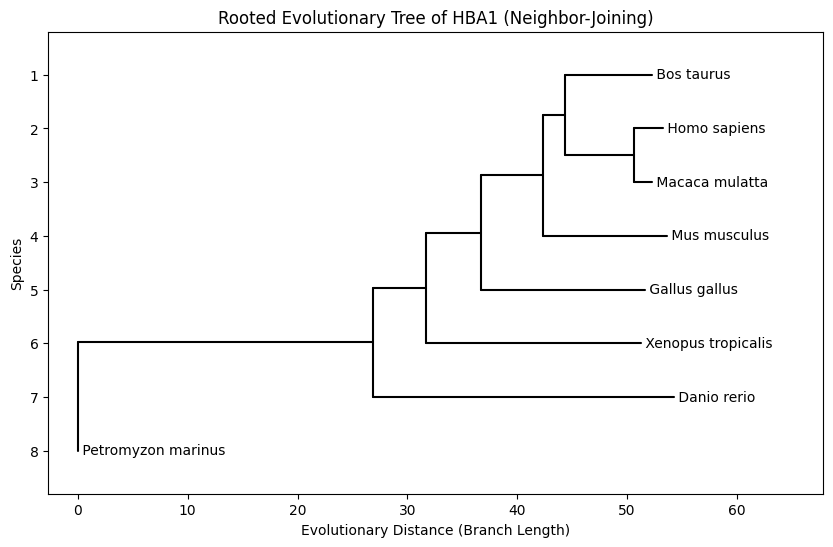

In [5]:
from Bio.Phylo.TreeConstruction import DistanceMatrix, DistanceTreeConstructor
from Bio import Phylo
import matplotlib.pyplot as plt

target_gene = "HBA1"
species_list = list(accession_db[target_gene].keys())
num_species = len(species_list)

print(f"Calculating lower-triangular distance matrix for {target_gene}...")

lower_triangular_matrix = []
for i in range(num_species):
    row = []
    for j in range(i + 1):
        if i == j:
            row.append(0.0)
        else:
            dist = get_distance(sequences[target_gene][species_list[i]], sequences[target_gene][species_list[j]])
            row.append(dist)
    lower_triangular_matrix.append(row)

dist_matrix = DistanceMatrix(names=species_list, matrix=lower_triangular_matrix)

constructor = DistanceTreeConstructor()
nj_tree = constructor.nj(dist_matrix)

# Explicitly root the tree using the outgroup
nj_tree.root_with_outgroup({"name": "Petromyzon marinus"})

fig, ax = plt.subplots(figsize=(10, 6))

# Updated label_func to hide internal node names like "Inner1"
Phylo.draw(nj_tree, axes=ax, do_show=False, label_func=lambda clade: clade.name if clade.is_terminal() else "")

plt.title(f"Rooted Evolutionary Tree of {target_gene} (Neighbor-Joining)")
plt.xlabel("Evolutionary Distance (Branch Length)")
plt.ylabel("Species")
plt.show()

### **Homework: The Molecular Clock**

The **molecular clock hypothesis** proposes that amino-acid substitutions in proteins accumulate at a roughly constant rate over evolutionary time.
If this is true, the number of sequence differences between two orthologous proteins should be proportional to the time since the two species diverged.

In this assignment you will:

1. Fetch orthologous protein sequences from the **UniProt** database.
2. Calculate **pairwise sequence identity** using global alignment.
3. Apply a **Poisson correction** to convert raw identity into evolutionary distance.
4. **Visualise** the results and evaluate whether each protein behaves as a molecular clock.

You will analyse three proteins with very different evolutionary rates:

| Protein | Gene | Role |
|---------|------|------|
| Cytochrome c | `CYCS` | Electron transport (a core enzyme in the mitochondrial electron transport chain essential for cellular respiration) — highly conserved |
| Haemoglobin α | `HBA1` | Oxygen transport (a subunit of the oxygen transport protein in red blood cells) — moderately conserved |
| Fibrinogen α | `FGA` | Blood clotting (a small peptide cleaved off and discarded during blood clot formation.) — fast-evolving |


In [3]:
# Install and import the libraries needed

!pip install biopython requests -q

import time

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import linregress
from Bio import Align
from Bio.Align import substitution_matrices


In [ ]:
# Data provided to solve the problem

# Approximate time since divergence from Homo sapiens, in MYA.
# These are teaching approximations.

species = {
  "Homo sapiens": 0,
  "Pan troglodytes": 6,
  "Gorilla gorilla": 10,
  "Pongo abelii": 15,
  "Macaca mulatta": 25,
  "Callithrix jacchus": 35,
  "Canis lupus familiaris": 95,
  "Felis catus": 95,
  "Bos taurus": 96,
  "Sus scrofa": 97,
  "Equus caballus": 100,
  "Mus musculus": 90,
  "Rattus norvegicus": 90,
  "Oryctolagus cuniculus": 97,
  "Monodelphis domestica": 160,
  "Gallus gallus": 320,
  "Anas platyrhynchos": 320,
  "Xenopus tropicalis": 360,
  "Danio rerio": 430,
}

# We study three proteins with very different evolutionary rates:
#   CYCS — cytochrome c           (highly conserved)
#   HBA1 — haemoglobin alpha      (moderately conserved)
#   FGA  — fibrinogen alpha chain (fast-evolving)

uniprot_db = {
  "CYCS": {
    "Homo sapiens": "P99999",
    "Pan troglodytes": "P99998",
    "Gorilla gorilla": "G4XXM2",
    "Pongo abelii": "Q5RFH4",
    "Macaca mulatta": "P00002",
    "Mus musculus": "P62897",
    "Rattus norvegicus": "P62898",
    "Bos taurus": "P62894",
    "Canis lupus familiaris": "P00011",
    "Gallus gallus": "P67881",
    "Danio rerio": "Q6IQM2"
  },
  "HBA1": {
    "Homo sapiens": "P69905",
    "Pan troglodytes": "P69907",
    "Pongo abelii": "A0A2J8R2J5",
    "Macaca mulatta": "I2CVH9",
    "Mus musculus": "P01942",
    "Rattus norvegicus": "P01946",
    "Bos taurus": "P01966",
    "Canis lupus familiaris": "P60529",
    "Gallus gallus": "P01994",
    "Danio rerio": "A0AC58IQ81"
  },
  "FGA": {
    "Homo sapiens": "P02671",
    "Pan troglodytes": "H2QQB5",
    "Pongo abelii": "A0A8I5YMH9",
    "Macaca mulatta": "F6UZ60",
    "Mus musculus": "E9PV24",
    "Rattus norvegicus": "P06399",
    "Bos taurus": "F6QND5",
    "Canis lupus familiaris": "A0A8I3NBI4",
    "Gallus gallus": "P14448",
    "Danio rerio": "B8A5L6"
  }
}

In [ ]:
# Fetch additional data from Uniprot DB

def fetch_uniprot_sequence(uniprot_id):
  """
  Download a UniProt protein sequence by accession.
  Returns the amino-acid string, or None on failure.
  """
  url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.json"
  try:
    response = requests.get(url, timeout=20)
    if response.status_code != 200:
      print(f"    FAILED {uniprot_id}: HTTP {response.status_code}")
      return None
    data = response.json()
    if "sequence" not in data:
      print(f"    FAILED {uniprot_id}: no sequence field")
      return None
    return data["sequence"]["value"]
  except Exception as e:
    print(f"    FAILED {uniprot_id}: {e}")
    return None


sequences = {gene: {} for gene in uniprot_db}
print("\nFetching sequences from UniProt...\n")
for gene, organisms in uniprot_db.items():
  print(f"=== {gene} ===")
  for organism, uid in organisms.items():
    sequence = fetch_uniprot_sequence(uid)
    if sequence is not None:
      sequences[gene][organism] = sequence
      print(f"  {organism:28s} {uid:12s} {len(sequence):4d} aa")
    time.sleep(0.15)
  print()


In [ ]:
# Setup aligner (provided)

aligner = Align.PairwiseAligner()
aligner.mode = "global"
aligner.substitution_matrix = substitution_matrices.load("BLOSUM62")
aligner.open_gap_score = -10
aligner.extend_gap_score = -1


##### **Task 1 — Sequence Identity**

Implement the function `calculate_identity(seq1, seq2)`.

**Algorithm:**

1. Use the pre-configured `aligner` (Biopython `PairwiseAligner`) to globally align the two sequences.  Take the first (best-scoring) alignment.
2. Format the alignment as a multi-line string using `alignment.format()`. Split on `"\n"` — the two aligned sequences are on lines 0 and 2.
3. Walk through the aligned columns with `zip()`.  For each position where **neither** character is `"-"` (a gap), count the column as *comparable*. If the two characters are equal, also count it as a *match*.
4. Return `matches / comparable`.  If `comparable == 0`, return `np.nan`.

> **Hint:**  `alignment.format().split("\n")` gives you the formatted lines.


In [ ]:
def calculate_identity(seq1, seq2):
  """
  Align two protein sequences globally and return the fraction
  of identical residues (ignoring gap-vs-gap columns).

  Steps:
    1. Use the global `aligner` to align seq1 and seq2.
        Take the first (best) alignment.
    2. Format the alignment as a string and extract the two
        aligned sequence lines (hint: alignment.format().split("\\n")
        gives lines; the sequences are on lines 0 and 2).
    3. Walk through the aligned positions with zip().
        For each column where NEITHER residue is '-', count it
        as "comparable".  If the residues are equal, also count
        it as a "match".
    4. Return  matches / comparable  (or np.nan if comparable == 0).

  Returns
  -------
  float
      Fraction identical (0.0 – 1.0), or np.nan.
  """

  # ---- YOUR CODE HERE ----
  raise NotImplementedError("Implement calculate_identity()")


##### **Task 2 — Poisson-Corrected Distance**

Implement the function `poisson_distance(identity)`.
The observed fraction of *different* residues is:
$$
p = 1 - \text{identity}
$$
Under a simple Poisson model, the corrected evolutionary distance is:
$$
d = -\ln(1 - p)
$$

This accounts for the possibility that the same site has been substituted more than once ("multiple hits").

- If $p \geq 1$, return `np.inf`.
- Otherwise, return $-\ln(1 - p)$.

> **Think about it:**  Why does raw percent difference underestimate the true number of substitutions for distantly related sequences?


In [ ]:
def poisson_distance(identity):
    """
    Convert fractional sequence identity to a Poisson-corrected
    evolutionary distance.
    The observed fraction of differing residues is  p = 1 − identity.
    Under a Poisson model of amino-acid substitution:
        d = −ln(1 − p)
    This corrects for the possibility of multiple substitutions
    at the same site ("multiple hits").

    Parameters
    ----------
    identity : float
        Fractional identity (0.0 – 1.0).

    Returns
    -------
    float
        Corrected evolutionary distance.
        Return np.inf if p >= 1 (sequences share no residues).
    """

    # ---- YOUR CODE HERE ----
    raise NotImplementedError("Implement poisson_distance()")


##### **Task 3 — Build the Data Table**

Loop over every gene in `sequences`.  For each gene:

1. Retrieve the human sequence (`"Homo sapiens"`).  Skip the gene if it is missing.
2. For every species in the `species` dictionary, retrieve the target sequence.
   Skip species with no fetched sequence.
3. Call `calculate_identity(human_seq, target_seq)`.
4. Call `poisson_distance(identity)`.
5. Append a dictionary to the `records` list with keys:

| Key | Value |
|-----|-------|
| `"Gene"` | gene name |
| `"Species"` | organism name |
| `"MYA"` | divergence time from the `species` dict |
| `"Identity"` | identity $\times 100$  (percent) |
| `"Difference"` | (1 - identity) $\times 100$  (percent) |
| `"Distance"` | Poisson-corrected distance |


In [ ]:
# For every gene, compare each species' sequence to Homo sapiens.
# Collect the results in a list of dictionaries with keys:
#   "Gene", "Species", "MYA", "Identity", "Difference", "Distance"
#
# Identity and Difference should be in PERCENT (0–100).
# Distance is the Poisson-corrected value.
#
# Skip species for which no sequence was fetched.
# Skip any gene where the human sequence is missing.
#
# Finally, create a DataFrame:  df = pd.DataFrame(records)

records = []

# ---- YOUR CODE HERE ----
raise NotImplementedError("Build the data table")

df = pd.DataFrame(records)
print("\n================ DATA USED ================\n")

print(df.sort_values(["Gene", "MYA"]).to_string(index=False, float_format=lambda x: f"{x:7.3f}"))



##### **Task 4 — Plot 1: Raw Sequence Identity**

Create a scatter plot of **% identity vs. divergence time (MYA)** for all
three genes on a single figure.

For each gene (use the provided `colors` dictionary):

- Plot data points with `plt.scatter()`.
- If there are ≥ 3 data points, fit a regression line using `linregress()` from `scipy.stats` and overlay it as a dashed line.
- Print the slope (in %/MYA) and $R^2$ value.

Set axis ranges to $x \in [0, 450]$ and $y \in [0, 105]$.  Add axis labels,
a title, legend, and grid.

In [ ]:
# Create a scatter plot:
#   x-axis: MYA (divergence time from human)
#   y-axis: Identity (%)
#
# For each gene:
#   • Plot the data points using plt.scatter()
#   • If there are >= 3 points, fit a line with linregress()
#     and overlay it as a dashed line
#   • Print the slope and R² value
#
# Label axes, add title, legend, and grid.
# Set x range [0, 450] and y range [0, 105].

# ---- YOUR CODE HERE ----
raise NotImplementedError("Create Plot 1")


##### **Task 5 — Plot 2: Corrected Evolutionary Distance**

Same as Plot 1, but plot **corrected evolutionary distance** on the y-axis
instead of raw identity.  Let matplotlib choose the y-axis range automatically.

Print the regression slope (in substitutions/site/MYA) and $R^2$ for each gene.

In [ ]:
# Same as Plot 1, but now use the "Distance" column on the y-axis.
# Do NOT fix the y-axis range (let matplotlib choose it).
# Print slope and R² for each gene.

# ---- YOUR CODE HERE ----
raise NotImplementedError("Create Plot 2")


##### **Questions (answer in a text cell)**

After completing the plots, answer the following questions:

1. **Which protein evolves the fastest?  Which is the most conserved?** Explain how you can tell from the plots.
2. **Look at the R² values.**  Which protein best fits a linear molecular clock? What might cause deviations from linearity?
3. **Compare Plot 1 (raw identity) to Plot 2 (corrected distance).** For which protein does the Poisson correction make the biggest difference?  Why?
4. **Why does the Poisson correction use  $d = -ln(1 - p)$  rather than simply  $d = p$ ?** What biological phenomenon does this correct for?
5. **Limitations.**  Name at least two reasons why a real molecular clock analysis would be more complex than what we did here.
